In [117]:
import graphviz as gv

In [118]:
class Graph:
    def __init__(self, vertices):
        self.V = vertices
        self.graph = []

    def add_edge(self, u, v, w):
        self.graph.append([u, v, w])


    def find(self, parent, i):
        if parent[i] == i:
            return i
        return self.find(parent, parent[i])

    def apply_union(self, parent, rank, x, y):
        xroot = self.find(parent, x)
        yroot = self.find(parent, y)
        if rank[xroot] < rank[yroot]:
            parent[xroot] = yroot
        elif rank[xroot] > rank[yroot]:
            parent[yroot] = xroot
        else:
            parent[yroot] = xroot
            rank[xroot] += 1

    def kruskal_algo(self):
        result = []
        i, e, tot_weight = 0, 0, 0
        self.graph = sorted(self.graph, key=lambda item: item[2])
        parent = []
        rank = []
        for node in range(self.V):
            parent.append(node)
            rank.append(0)
        while e < self.V - 1:
            u, v, w = self.graph[i]
            i = i + 1
            x = self.find(parent, u)
            y = self.find(parent, v)
            if x != y:
                e = e + 1
                result.append([u, v, w])
                self.apply_union(parent, rank, x, y)
        for u, v, weight in result:
            tot_weight = tot_weight + weight
            print("%d - %d: %d" % (u, v, weight))

        print("Costo total del MST para el grafo: ", tot_weight)

In [119]:
def readAdjl(fn, haslabels=False, weighted=False, sep="|"):
  with open(fn) as f:
    labels = None
    if haslabels:
      labels = f.readline().strip().split()
    L = []
    for line in f:
      if weighted:
        L.append([tuple(map(int, p.split(sep))) for p in line.strip().split()])
        # line => "1|3 2|5 4|4" ==> [(1, 3), (2, 5), (4, 4)]
      else: 
        L.append(list(map(int, line.strip().split()))) # "1 3 5" => [1, 3, 5]
        # L.append([int(x) for x in line.strip().split()])
  return L, labels

def adjlShow(L, labels=None, directed=False, weighted=False, path=[],
             layout="sfdp"):
  g = gv.Digraph("G") if directed else gv.Graph("G")
  g.graph_attr["layout"] = layout
  g.edge_attr["color"] = "black"
  g.node_attr["color"] = "blue"
  g.node_attr["width"] = "0.1"
  g.node_attr["height"] = "0.1"
  g.node_attr["fontsize"] = "8"
  g.node_attr["fontcolor"] = "mediumslateblue"
  g.node_attr["fontname"] = "monospace"
  g.edge_attr["fontsize"] = "8"
  g.edge_attr["fontname"] = "monospace"
  n = len(L)
  for u in range(n):
    g.node(str(u), labels[u] if labels else str(u))
  added = set()
  for v, u in enumerate(path):
    if u != None:
      if weighted:
        for vi, w in G[u]:
          if vi == v:
            break
        g.edge(str(u), str(v), str(w), dir="forward", penwidth="2", color="blue")
      else:
        g.edge(str(u), str(v), dir="forward", penwidth="2", color="blue")
      added.add(f"{u},{v}")
      added.add(f"{v},{u}")
  if weighted:
    for u in range(n):
      for v, w in L[u]:
        if not directed and not f"{u},{v}" in added:
          added.add(f"{u},{v}")
          added.add(f"{v},{u}")
          g.edge(str(u), str(v), str(w))
        elif directed:
          g.edge(str(u), str(v), str(w))
  else:
    for u in range(n):
      for v in L[u]:
        if not directed and not f"{u},{v}" in added:
          added.add(f"{u},{v}")
          added.add(f"{v},{u}")
          g.edge(str(u), str(v))
        elif directed:
          g.edge(str(u), str(v))
  return g

In [120]:
%%file 1.in
1|4 7|8
0|4 
8|2 5|4 3|7
4|9 2|7
3|9
2|4 6|2
5|2 7|1
6|1 0|8
2|2

Overwriting 1.in


 0: [(1, 4), (7, 8)]
 1: [(0, 4)]
 2: [(8, 2), (5, 4), (3, 7)]
 3: [(4, 9), (2, 7)]
 4: [(3, 9)]
 5: [(2, 4), (6, 2)]
 6: [(5, 2), (7, 1)]
 7: [(6, 1), (0, 8)]
 8: [(2, 2)]


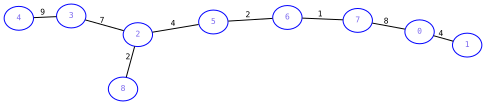

In [121]:
G, _ = readAdjl("1.in", weighted=True)
for i, edges in enumerate(G):
  print(f"{i:2}: {edges}")
adjlShow(G, weighted=True)

In [148]:
g = Graph(9)
g.add_edge(0, 1, 4)
g.add_edge(0, 7, 1)
g.add_edge(1, 0, 4)
g.add_edge(2, 3, 7)
g.add_edge(2, 5, 4)
g.add_edge(2, 8, 2)
g.add_edge(3, 2, 7)
g.add_edge(3, 4, 9)
g.add_edge(4, 3, 9)
g.add_edge(5, 2, 4)
g.add_edge(5, 6, 3)
g.add_edge(6, 5, 3)
g.add_edge(6, 7, 7)
g.add_edge(7, 0, 8)
g.add_edge(7, 6, 7)
g.add_edge(8, 2, 9)

In [149]:
g.kruskal_algo()

0 - 7: 1
2 - 8: 2
5 - 6: 3
0 - 1: 4
2 - 5: 4
2 - 3: 7
6 - 7: 7
3 - 4: 9
Costo total del MST para el grafo:  37
